(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


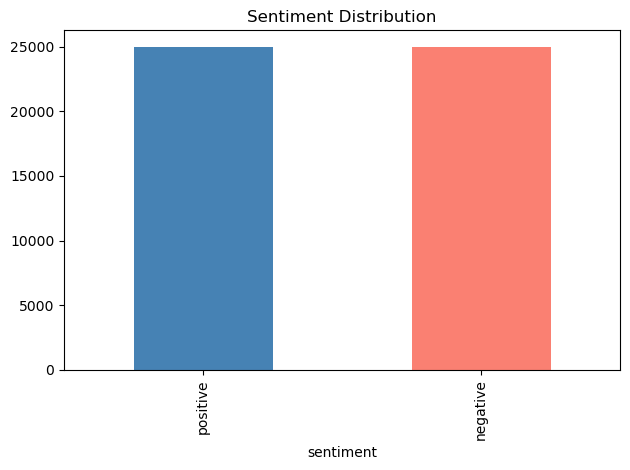

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/IMDB Dataset.csv')
print(df.shape)
print(df.head())
print(df['sentiment'].value_counts())

df['sentiment'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Sentiment Distribution')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

In [2]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)       # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text) # remove punctuation
    text = text.lower().strip()
    return text

df['clean_review'] = df['review'].apply(clean_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(df[['clean_review', 'label']].head())

                                        clean_review  label
0  one of the other reviewers has mentioned that ...      1
1  a wonderful little production the filming tech...      1
2  i thought this was a wonderful way to spend ti...      1
3  basically theres a family where a little boy j...      0
4  petter matteis love in the time of money is a ...      1


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train size:", X_train_tfidf.shape)
print("Test size:", X_test_tfidf.shape)

Train size: (40000, 10000)
Test size: (10000, 10000)


              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



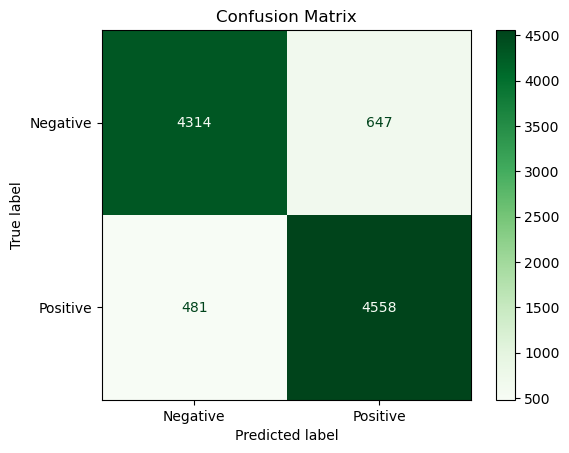

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative','Positive'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

In [5]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    confidence = model.predict_proba(vectorized)[0].max()
    label = "Positive 😊" if prediction == 1 else "Negative 😞"
    print(f"Review: {text}")
    print(f"Sentiment: {label} (confidence: {confidence:.2f})")

predict_sentiment("This movie was absolutely brilliant, I loved every second!")
predict_sentiment("Terrible film, complete waste of time.")

Review: This movie was absolutely brilliant, I loved every second!
Sentiment: Positive 😊 (confidence: 0.99)
Review: Terrible film, complete waste of time.
Sentiment: Negative 😞 (confidence: 1.00)
